In [7]:
# === Backtesting Engine: 2021 - 2023 (Monthly Rebalance, 3-Month Rolling Window) ===

import yfinance as yf
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print("Starting Setup for Backtesting (2021-2023)...")

Starting Setup for Backtesting (2021-2023)...


In [8]:
# 1. Konfigurasi
tickers = ['DUK', 'MSFT', 'CVX', 'TSLA']
K = 2
penalty_A = 5.0
depth = 2  # Kedalaman Ansatz EfficientSU2
maxiter = 100 # Iterasi SPSA

# Parameter Kalender
initial_capital = 100_000_000.0
# Di bursa, 1 bulan ~ 21 hari perdagangan, 3 bulan ~ 63 hari perdagangan
lookback_days = 63 
rebalance_days = 21 

# 2. Download Data
data = yf.download(tickers, start="2020-09-01", end="2024-01-01", progress=False)['Close']
data = data.dropna()
data_clean = data.sort_index()

print(f"Data Berhasil Diunduh. Total hari observasi: {len(data_clean)}")

Data Berhasil Diunduh. Total hari observasi: 838


In [ ]:
# Helper Functions: Markowitz QUBO -> Ising Hamiltonian -> VQE
def compute_endogenous_lambda(log_returns, tickers):
    mu_annual = log_returns[tickers].mean() * 252
    sigma_annual = log_returns[tickers].std() * np.sqrt(252)
    mu_avg = abs(mu_annual).mean()
    sigma_avg = sigma_annual.mean()
    if np.isnan(mu_avg) or np.isnan(sigma_avg) or (mu_avg + sigma_avg) == 0:
        return 0.5 
    # Sigmoid / Logistic function based on Sharpe Ratio
    Z = mu_avg / sigma_avg
    return 1.0 / (1.0 + np.exp(Z))

def build_hamiltonian(h, J, n_assets, offset=0.0):
    """Bangun Ising Hamiltonian dari parameter h_i, J_ij, dan offset.
    Penalty constraint sudah ter-encode di dalam koefisien QUBO.
    H = sum_i h_i Z_i + sum_{i<j} J_ij Z_i Z_j + offset * I
    """
    coeffs = []
    obs = []
    
    # Suku linear (field lokal)
    for i in range(n_assets):
        if abs(h[i]) > 1e-10:
            coeffs.append(float(h[i]))
            obs.append(qml.PauliZ(i))
            
    # Suku interaksi (kopling)
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            if abs(J[i, j]) > 1e-10:
                coeffs.append(float(J[i, j]))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
                
    # Energy offset (konstanta)
    if abs(offset) > 1e-10:
        coeffs.append(float(offset))
        obs.append(qml.Identity(0))
        
    return qml.Hamiltonian(coeffs, obs)

def run_vqe_spsa_pennylane(H, n_qubits, K=2, depth=1, maxiter=100, seed=42):
    # Gunakan device statik tanpa tembakan untuk optimasi kecepatan
    dev = qml.device("default.qubit", wires=n_qubits)
    
    @qml.qnode(dev)
    def cost_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
        return qml.expval(H)

    rng = np.random.default_rng(seed)
    n_params = n_qubits * 2 * (depth + 1)
    params = rng.uniform(0, 2 * np.pi, n_params)
    
    # SPSA Configuration manual update
    a = 0.1 
    c = 0.1
    A = maxiter * 0.1
    alpha = 0.602
    gamma = 0.101
    
    for k in range(maxiter):
        a_k = a / (A + k + 1) ** alpha
        c_k = c / (k + 1) ** gamma
        delta = 2 * rng.integers(0, 2, size=n_params) - 1
        
        cost_plus = float(cost_circuit(params + c_k * delta))
        cost_minus = float(cost_circuit(params - c_k * delta))
        grad = (cost_plus - cost_minus) / (2 * c_k * delta)
        params = params - a_k * grad

    # Penarikan bitstring dari hasil amplitudo
    @qml.qnode(dev)
    def prob_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
        return qml.probs(wires=range(n_qubits))

    probs = prob_circuit(params)
    
    # Pilih kombinasi K aset dengan probabilitas tertinggi 
    sorted_indices = np.argsort(probs)[::-1]
    best_bitstring = None
    for idx in sorted_indices:
        bs = format(idx, f'0{n_qubits}b')
        if bs.count('1') == K:
            best_bitstring = bs
            break
            
    if best_bitstring is None:
        best_bitstring = "0" * (n_qubits - K) + "1" * K # Fallback if SPSA gets highly trapped
        
    # Translate bitstring ('1' artinya dipilih, karena Penalty constraint Z Z mencari eigen -1/-1)
    selected_indices = [i for i, bit in enumerate(best_bitstring) if bit == '1']
    return selected_indices

In [10]:
def run_strategy_step(lookback_data, tickers, K=2, penalty_A=5.0):
    """Strategi seleksi aset berbasis Markowitz QUBO → Ising → VQE.
    
    Bias (h_i) dan kopling (J_ij) diturunkan murni dari:
    - Expected return (mu_i)
    - Varians (sigma_i^2)
    - Kovarians (Sigma_ij)
    sesuai penurunan di Markowitz_QUBO.md §3-§4.
    """
    log_rets = np.log(lookback_data / lookback_data.shift(1)).dropna()
    n_assets = len(tickers)
    
    # --- Langkah 1: Hitung statistik dari data ---
    # Expected return tahunan (mu_i)
    mu_annual = log_rets[tickers].mean() * 252
    # Matriks kovarians tahunan (Sigma_ij)
    cov_annual = log_rets[tickers].cov() * 252
    # Varians tahunan (sigma_i^2 = diagonal kovarians)
    var_annual = np.diag(cov_annual.values)
    
    # Risk aversion endogen (lambda)
    lam = compute_endogenous_lambda(log_rets, tickers)
    
    # --- Langkah 2: Hitung koefisien QUBO ---
    # C_i = sigma_i^2 - lambda*mu_i + A*(1 - 2K)   [linear]
    # Q_ij = 2*Sigma_ij + 2*A                       [interaksi, untuk i < j]
    C = np.zeros(n_assets)
    for i in range(n_assets):
        C[i] = var_annual[i] - lam * mu_annual.iloc[i] + penalty_A * (1 - 2 * K)
    
    Q = np.zeros((n_assets, n_assets))
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            Q[i, j] = 2 * cov_annual.iloc[i, j] + 2 * penalty_A
            Q[j, i] = Q[i, j]  # simetris
    
    # --- Langkah 3: Transformasi QUBO → Ising ---
    # x_i = (1 - s_i) / 2
    # J_ij = Q_ij / 4
    # h_i  = -C_i/2 - (1/4) * sum_{j != i} Q_ij
    # offset = sum_{i<j} Q_ij/4 + sum_i C_i/2 + A*K^2
    
    J_ising = np.zeros((n_assets, n_assets))
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            J_ising[i, j] = Q[i, j] / 4.0
    
    h_ising = np.zeros(n_assets)
    for i in range(n_assets):
        sum_Q = 0.0
        for j in range(n_assets):
            if j != i:
                sum_Q += Q[i, j]
        h_ising[i] = -C[i] / 2.0 - sum_Q / 4.0
    
    offset = 0.0
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            offset += Q[i, j] / 4.0
    for i in range(n_assets):
        offset += C[i] / 2.0
    offset += penalty_A * K**2
    
    # --- Langkah 4: Susun Hamiltonian & Optimasi VQE ---
    H = build_hamiltonian(h_ising, J_ising, n_assets, offset)
    selected_indices = run_vqe_spsa_pennylane(H, n_assets, K, depth, maxiter)
    
    return selected_indices





In [11]:

# === MAIN BACKTEST LOOP ===
# Filter start data untuk memastikan kita mulai observasi (rebalancing) pada Januari 2021
# Kita cari indeks di data_clean terdekat dengan awal Jan 2021
start_bt_date = pd.to_datetime('2021-01-04')
start_idx = np.searchsorted(data_clean.index, start_bt_date)

rebalance_indices = range(start_idx, len(data_clean), rebalance_days)

# Tracking Array
value_vqe = [initial_capital] * start_idx
value_bench = [initial_capital] * start_idx
value_assets = {t: [initial_capital] * start_idx for t in tickers}

holdings_vqe, holdings_bench = np.zeros(len(tickers)), np.zeros(len(tickers))
cash_vqe, cash_bench = initial_capital, initial_capital
cash_assets = {t: initial_capital for t in tickers}
holdings_assets = {t: 0.0 for t in tickers}

print(f"\n--- Memulai Backtest dari {data_clean.index[start_idx].date()} hingga {data_clean.index[-1].date()} ---")

for i, curr_idx in enumerate(rebalance_indices):
    curr_date = data_clean.index[curr_idx]
    train_start_idx = max(0, curr_idx - lookback_days)
    train_data = data_clean.iloc[train_start_idx:curr_idx]
    
    next_idx = rebalance_indices[i+1] if i+1 < len(rebalance_indices) else len(data_clean)
    
    # 1. Alokasi Portofolio VQE
    selected_indices = run_strategy_step(train_data, tickers, K=K)
    print(f"[{curr_date.date()}] VQE Terpilih: {[tickers[idx] for idx in selected_indices]}")
    
    target_w_vqe = np.zeros(len(tickers))
    if len(selected_indices) > 0:
        weight = 1.0 / len(selected_indices)
        for idx in selected_indices:
            target_w_vqe[idx] = weight
            
    # Alokasi Buy & Hold Equal (Benchmark ke 4 aset)
    target_w_bench = np.full(len(tickers), 1.0 / len(tickers))
    
    # 2. Fungsi Eksekusi Rebalance Bebas Biaya Transaksi (Atau bisa ditambahkan)
    current_prices = data_clean.iloc[curr_idx].values
    def rebalance_portfolio(current_cash, current_holdings, target_weights, prices):
        total_value = current_cash + np.sum(current_holdings * prices)
        target_values = total_value * target_weights
        
        new_holdings = current_holdings.copy()
        new_cash = current_cash
        
        # Jual aset berlebih
        for j in range(len(tickers)):
            c_val = current_holdings[j] * prices[j]
            if c_val > target_values[j]:
                sell_val = c_val - target_values[j]
                shares_sold = sell_val / prices[j]
                new_cash += sell_val
                new_holdings[j] -= shares_sold
        
        # Beli menggunakan cash
        for j in range(len(tickers)):
            c_val = new_holdings[j] * prices[j]
            if c_val < target_values[j]:
                buy_val = target_values[j] - c_val
                if new_cash < buy_val: buy_val = new_cash
                shares_bought = buy_val / prices[j]
                new_cash -= buy_val
                new_holdings[j] += shares_bought
                
        return new_cash, new_holdings

    # Eksekusi VQE dan Benchmark
    cash_vqe, holdings_vqe = rebalance_portfolio(cash_vqe, holdings_vqe, target_w_vqe, current_prices)
    # Buy & Hold benchmark All Asset dieksekusi sekali di awal indeks saja
    if i == 0:
        cash_bench, holdings_bench = rebalance_portfolio(cash_bench, holdings_bench, target_w_bench, current_prices)
    
    # Eksekusi Single Assets
    if i == 0:
        for j, t in enumerate(tickers):
            target_w_indiv = np.zeros(len(tickers))
            target_w_indiv[j] = 1.0
            c_t, h_t = rebalance_portfolio(cash_assets[t], np.zeros(len(tickers)), target_w_indiv, current_prices)
            cash_assets[t] = c_t
            holdings_assets[t] = h_t[j]

    # 3. Trajectory / Mark to Market
    start_d = curr_idx if i == 0 else curr_idx + 1
    for d in range(start_d, next_idx):
        prices = data_clean.iloc[d].values
        
        value_vqe.append(cash_vqe + np.sum(holdings_vqe * prices))
        value_bench.append(cash_bench + np.sum(holdings_bench * prices))
        
        for j, t in enumerate(tickers):
            value_assets[t].append(cash_assets[t] + holdings_assets[t] * prices[j])

print("Backtesting Selesai.")


--- Memulai Backtest dari 2021-01-04 hingga 2023-12-29 ---
[2021-01-04] VQE Terpilih: ['MSFT', 'TSLA']
[2021-02-03] VQE Terpilih: ['MSFT', 'TSLA']
[2021-03-05] VQE Terpilih: ['MSFT', 'TSLA']
[2021-04-06] VQE Terpilih: ['MSFT', 'TSLA']
[2021-05-05] VQE Terpilih: ['MSFT', 'TSLA']
[2021-06-04] VQE Terpilih: ['MSFT', 'TSLA']
[2021-07-06] VQE Terpilih: ['MSFT', 'TSLA']
[2021-08-04] VQE Terpilih: ['MSFT', 'TSLA']
[2021-09-02] VQE Terpilih: ['MSFT', 'TSLA']
[2021-10-04] VQE Terpilih: ['MSFT', 'TSLA']
[2021-11-02] VQE Terpilih: ['MSFT', 'TSLA']
[2021-12-02] VQE Terpilih: ['MSFT', 'TSLA']
[2022-01-03] VQE Terpilih: ['MSFT', 'TSLA']
[2022-02-02] VQE Terpilih: ['MSFT', 'TSLA']
[2022-03-04] VQE Terpilih: ['DUK', 'TSLA']
[2022-04-04] VQE Terpilih: ['DUK', 'TSLA']
[2022-05-04] VQE Terpilih: ['DUK', 'TSLA']
[2022-06-03] VQE Terpilih: ['DUK', 'TSLA']
[2022-07-06] VQE Terpilih: ['DUK', 'TSLA']
[2022-08-04] VQE Terpilih: ['DUK', 'TSLA']
[2022-09-02] VQE Terpilih: ['DUK', 'TSLA']
[2022-10-04] VQE Terpil

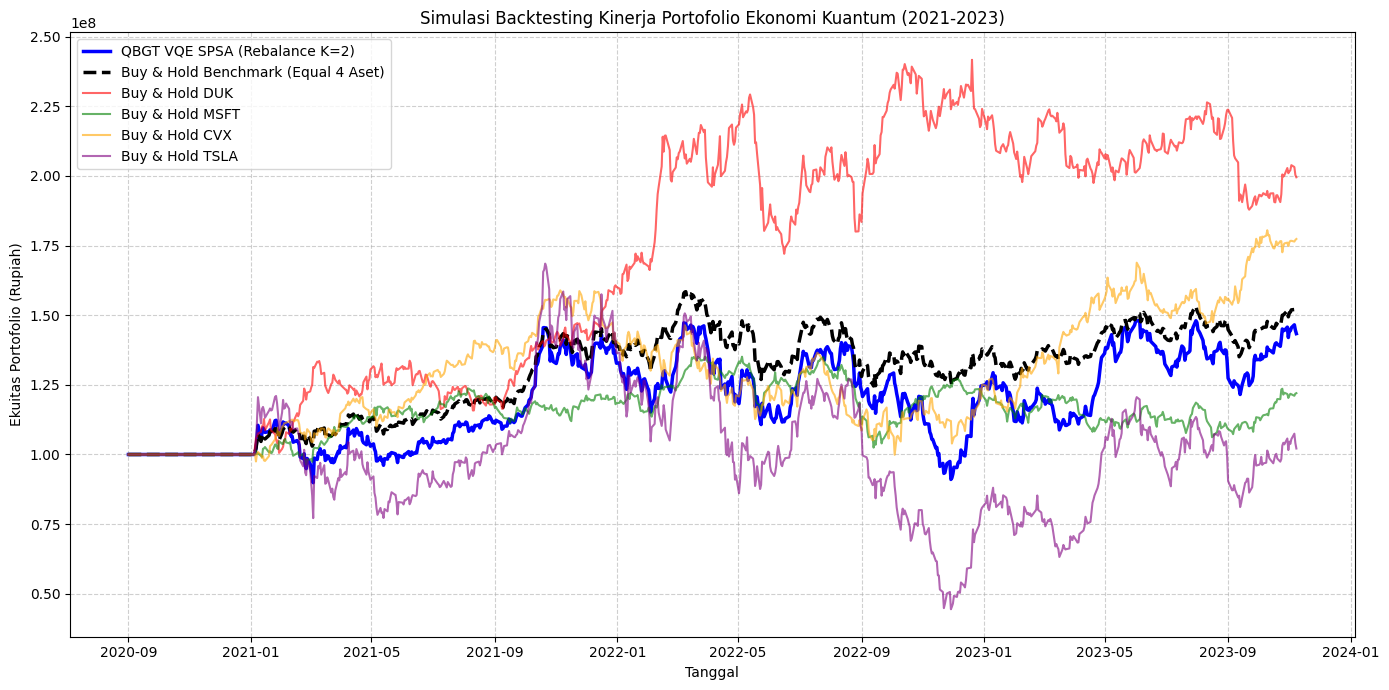

In [ ]:
# === VISUALISASI PERTUMBUHAN PORTOFOLIO ===
plt.figure(figsize=(14, 7))

# Plot VQE Strategy
plt.plot(data_clean.index[:len(value_vqe)], value_vqe, label=f'QBGT VQE SPSA (Rebalance K={K})', linewidth=2.5, color='blue')

# Plot Buy & Hold All Equal Weights
plt.plot(data_clean.index[:len(value_bench)], value_bench, label=f'Buy & Hold Benchmark (Equal {len(tickers)} Aset)', linewidth=2.5, color='black', linestyle='--')

# Plot Individual Buy & Hold
colors = ['red', 'green', 'orange', 'purple', 'pink', 'grey', 'cyan', 'magenta']
for j, t in enumerate(tickers):
    plt.plot(data_clean.index[:len(value_assets[t])], value_assets[t], label=f'Buy & Hold {t}', color=colors[j], alpha=0.6)

plt.title('Simulasi Backtesting Kinerja Portofolio Ekonomi Kuantum (2021-2023)')
plt.ylabel('Ekuitas Portofolio (Rupiah)')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()